# **Import môi trường**

In [20]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from dotenv import load_dotenv
from fredapi import Fred

# **Đọc FRED API key**

In [2]:
project_root = Path.cwd()
env_path = project_root / ".env"

load_dotenv(env_path)

fred_api_key = os.getenv("FRED_API_KEY")

if fred_api_key is None:
    raise ValueError(
        "Không tìm thấy FRED_API_KEY. Hãy kiểm tra file .env."
    )

print("Đã tìm thấy FRED API key.")

Đã tìm thấy FRED API key.


# **Khởi tạo kết nối FRED**

In [3]:
fred = Fred(api_key=fred_api_key)

print("Đã khởi tạo kết nối FRED.")

Đã khởi tạo kết nối FRED.


# **Lấy thử dữ liệu Treasury bill**

In [ ]:
# Lấy dữ liệu Treasury Bill 3-Month (TB3MS) từ FRED bắt đầu từ ngày 1 tháng 1 năm 2024
tb3ms_test = fred.get_series(
    "TB3MS",
    observation_start="2024-01-01"
)

tb3ms_test.tail()

2024-01-01    5.22
2024-02-01    5.24
2024-03-01    5.24
2024-04-01    5.24
2024-05-01    5.25
dtype: float64

In [ ]:
# Kiểm tra thông tin về chuỗi dữ liệu TB3MS
tb3ms_info = fred.get_series_info("TB3MS")

tb3ms_info[
    [
        "title",
        "units",
        "frequency",
        "seasonal_adjustment",
        "observation_start",
        "observation_end"
    ]
]

title                  3-Month Treasury Bill Secondary Market Rate, D...
units                                                            Percent
frequency                                                        Monthly
seasonal_adjustment                              Not Seasonally Adjusted
observation_start                                             1934-01-01
observation_end                                               2026-07-01
dtype: str

## **1. Nominal interest rate**

The nominal interest rate is represented by the three-month U.S. Treasury
bill secondary market rate.

- FRED series: `TB3MS`
- Unit: Percent per year
- Frequency: Monthly
- Seasonal adjustment: Not seasonally adjusted
- Source: Federal Reserve Board, H.15 Selected Interest Rates

In [7]:
# Xác định ngày bắt đầu phân tích
START_DATE = "2000-01-01"

print(f"Analysis starts from: {START_DATE}")

Analysis starts from: 2000-01-01


In [8]:
# Lấy dữ liệu Treasury Bill 3-Month (TB3MS) từ FRED bắt đầu từ ngày 1 tháng 1 năm 2000
tb3ms = fred.get_series(
    "TB3MS",
    observation_start=START_DATE
)

type(tb3ms) 

pandas.Series

In [ ]:
# Tạo DataFrame cho lãi suất danh nghĩa
nominal_df = (
    tb3ms
    .rename("nominal_rate")
    .to_frame()
)

nominal_df.index.name = "date"

nominal_df.head()

,nominal_rate
date,
2000-01-01,5.32
2000-02-01,5.55
2000-03-01,5.69
2000-04-01,5.66
2000-05-01,5.79


In [11]:
display("Dữ liệu đầu: ", nominal_df.head())
display("Dữ liệu cuối: ", nominal_df.tail())

'Dữ liệu đầu: '

,nominal_rate
date,
2000-01-01,5.32
2000-02-01,5.55
2000-03-01,5.69
2000-04-01,5.66
2000-05-01,5.79


'Dữ liệu cuối: '

,nominal_rate
date,
2026-03-01,3.61
2026-04-01,3.61
2026-05-01,3.60
2026-06-01,3.66
2026-07-01,3.73


In [ ]:
# Kiểm tra số lượng quan sát và số lượng cột trong DataFrame
print(f"Number of observations: {len(nominal_df)}")
print(f"Number of columns: {nominal_df.shape[1]}")

Number of observations: 319
Number of columns: 1


In [14]:
nominal_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 319 entries, 2000-01-01 to 2026-07-01
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nominal_rate  319 non-null    float64
dtypes: float64(1)
memory usage: 5.0 KB


In [15]:
# Kiểm tra giá trị thiếu trong DataFrame
missing_values = nominal_df.isna().sum()

missing_values

nominal_rate    0
dtype: int64

In [16]:
# kiểm tra các ngày trùng lặp trong DataFrame
duplicate_dates = nominal_df.index.duplicated().sum()

print("Number of duplicate dates:", duplicate_dates)

Number of duplicate dates: 0


In [17]:
nominal_df["nominal_rate"].describe()

count    319.000000
mean       1.927743
std        1.928863
min        0.010000
25%        0.120000
50%        1.290000
75%        3.685000
max        6.170000
Name: nominal_rate, dtype: float64

In [18]:
# Tìm tháng có lãi suất danh nghĩa thấp nhất
minimum_date = nominal_df["nominal_rate"].idxmin()
minimum_value = nominal_df.loc[minimum_date, "nominal_rate"]

print("Minimum date:", minimum_date)
print("Minimum rate:", minimum_value)

Minimum date: 2011-09-01 00:00:00
Minimum rate: 0.01


In [19]:
# Tìm tháng có lãi suất danh nghĩa cao nhất
maximum_date = nominal_df["nominal_rate"].idxmax()
maximum_value = nominal_df.loc[maximum_date, "nominal_rate"]

print("Maximum date:", maximum_date)
print("Maximum rate:", maximum_value)

Maximum date: 2000-11-01 00:00:00
Maximum rate: 6.17


In [23]:
# Lưu dữ liệu thành CSV
raw_data_directory = project_root / "data" / "raw"
raw_data_directory.mkdir(parents=True, exist_ok=True)

nominal_file = raw_data_directory / "tb3ms_monthly.csv"
nominal_df.to_csv(nominal_file)

print(f"Saved to: {nominal_file}")

Saved to: d:\Project_Intern\us-real-interest-rate-analysis\data\raw\tb3ms_monthly.csv


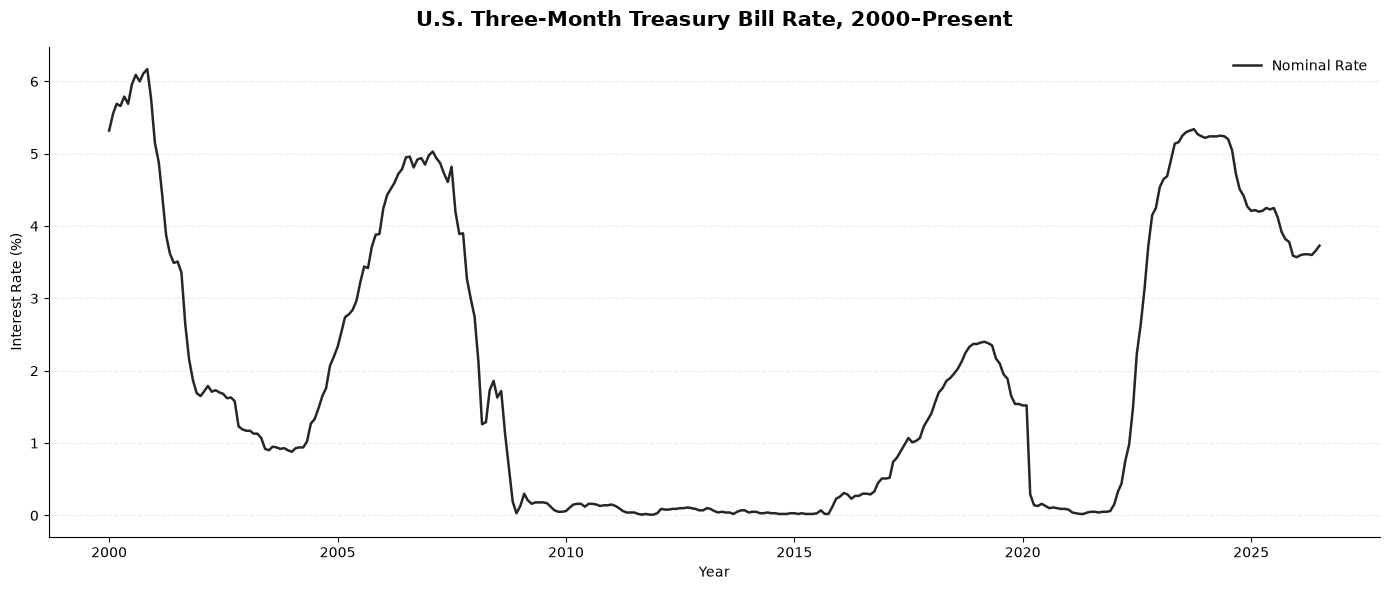

Figure saved to: d:\Project_Intern\us-real-interest-rate-analysis\outputs\tb3ms_nominal_rate.png


In [24]:
# Vẽ biểu đồ lãi suất danh nghĩa theo thời gian
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    nominal_df.index,
    nominal_df["nominal_rate"],
    color="#262626",
    linewidth=1.8,
    label="Nominal Rate"
)

ax.set_title(
    "U.S. Three-Month Treasury Bill Rate, 2000–Present",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Interest Rate (%)")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

output_directory = project_root / "outputs"
output_directory.mkdir(parents=True, exist_ok=True)

figure_file = output_directory / "tb3ms_nominal_rate.png"

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_file}")

## **2. Expected inflation**

Expected inflation is represented by the Cleveland Fed's one-year expected
inflation estimate.

- FRED series: `EXPINF1YR`
- Unit: Percent per year
- Frequency: Monthly
- Source: Federal Reserve Bank of Cleveland
- Method: Model-based estimate

Expected inflation is not directly observable. The Cleveland Fed estimates it
using information from Treasury yields, inflation data, inflation swaps, and
survey-based inflation expectations.

The expected real interest rate is approximated as:

\[
r_t^{ex\ ante} \approx i_t - \pi_t^e
\]

In [25]:
# Lấy thông tin về lạm phát dự kiến trong 1 năm (EXPINF1YR) từ FRED
expected_inflation_info = fred.get_series_info("EXPINF1YR")

expected_inflation_info[
    [
        "title",
        "units",
        "frequency",
        "seasonal_adjustment",
        "observation_start",
        "observation_end"
    ]
]

title                  1-Year Expected Inflation
units                                    Percent
frequency                                Monthly
seasonal_adjustment      Not Seasonally Adjusted
observation_start                     1982-01-01
observation_end                       2026-08-01
dtype: str

In [ ]:
# Lấy dữ liệu lạm phát dự kiến trong 1 năm (EXPINF1YR) từ FRED bắt đầu từ ngày 1 tháng 1 năm 2000
expected_inflation = fred.get_series(
    "EXPINF1YR",
    observation_start=START_DATE
)

type(expected_inflation)

pandas.Series

In [ ]:
# Tạo DataFrame cho lạm phát dự kiến
expected_df = (
    expected_inflation
    .rename("expected_inflation")
    .to_frame()
)

expected_df.index.name = "date"

expected_df.head()

,expected_inflation
date,
2000-01-01,3.080288
2000-02-01,3.157068
2000-03-01,3.238857
2000-04-01,3.160674
2000-05-01,3.312626


In [28]:
display("Dữ liệu đầu: ", expected_df.head())
display("Dữ liệu cuối: ", expected_df.tail())

'Dữ liệu đầu: '

,expected_inflation
date,
2000-01-01,3.080288
2000-02-01,3.157068
2000-03-01,3.238857
2000-04-01,3.160674
2000-05-01,3.312626


'Dữ liệu cuối: '

,expected_inflation
date,
2026-04-01,3.276398
2026-05-01,3.535256
2026-06-01,3.038866
2026-07-01,2.386001
2026-08-01,2.393703


In [29]:
print("Number of observations:", len(expected_df))
print("Start date:", expected_df.index.min())
print("End date:", expected_df.index.max())

Number of observations: 320
Start date: 2000-01-01 00:00:00
End date: 2026-08-01 00:00:00


In [30]:
expected_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 320 entries, 2000-01-01 to 2026-08-01
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   expected_inflation  320 non-null    float64
dtypes: float64(1)
memory usage: 5.0 KB


In [31]:
# Kiểm tra giá trị thiếu
expected_df.isna().sum()

expected_inflation    0
dtype: int64

In [32]:
# Kiểm tra ngày trùng lặp trong DataFrame
print(
    "Number of duplicate dates:",
    expected_df.index.duplicated().sum()
)

Number of duplicate dates: 0


In [33]:
expected_df["expected_inflation"].describe()

count    320.000000
mean       2.090451
std        0.690604
min       -0.480678
25%        1.649175
50%        2.074494
75%        2.615469
max        4.226713
Name: expected_inflation, dtype: float64

In [34]:
# Tìm tháng có lạm phát dự kiến thấp nhất
minimum_date = expected_df["expected_inflation"].idxmin()
minimum_value = expected_df.loc[minimum_date, "expected_inflation"]

print(f"Tháng có lạm phát dự kiến thấp nhất: {minimum_date}")
print(f"Giá trị lạm phát dự kiến thấp nhất: {minimum_value}")

Tháng có lạm phát dự kiến thấp nhất: 2009-03-01 00:00:00
Giá trị lạm phát dự kiến thấp nhất: -0.48067803


In [35]:
# Tìm tháng có lạm phát dự kiến cao nhất
maximum_date = expected_df["expected_inflation"].idxmax()
maximum_value = expected_df.loc[maximum_date, "expected_inflation"]

print(f"Tháng có lạm phát dự kiến cao nhất: {maximum_date}")
print(f"Giá trị lạm phát dự kiến cao nhất: {maximum_value}")

Tháng có lạm phát dự kiến cao nhất: 2022-06-01 00:00:00
Giá trị lạm phát dự kiến cao nhất: 4.22671337


In [38]:
# Lưu dữ liệu lạm phát dự kiến thành CSV
expected_file = raw_data_directory / "expected_inflation.csv"
expected_df.to_csv(expected_file)
print(f"Saved to: {expected_file}")

Saved to: d:\Project_Intern\us-real-interest-rate-analysis\data\raw\expected_inflation.csv


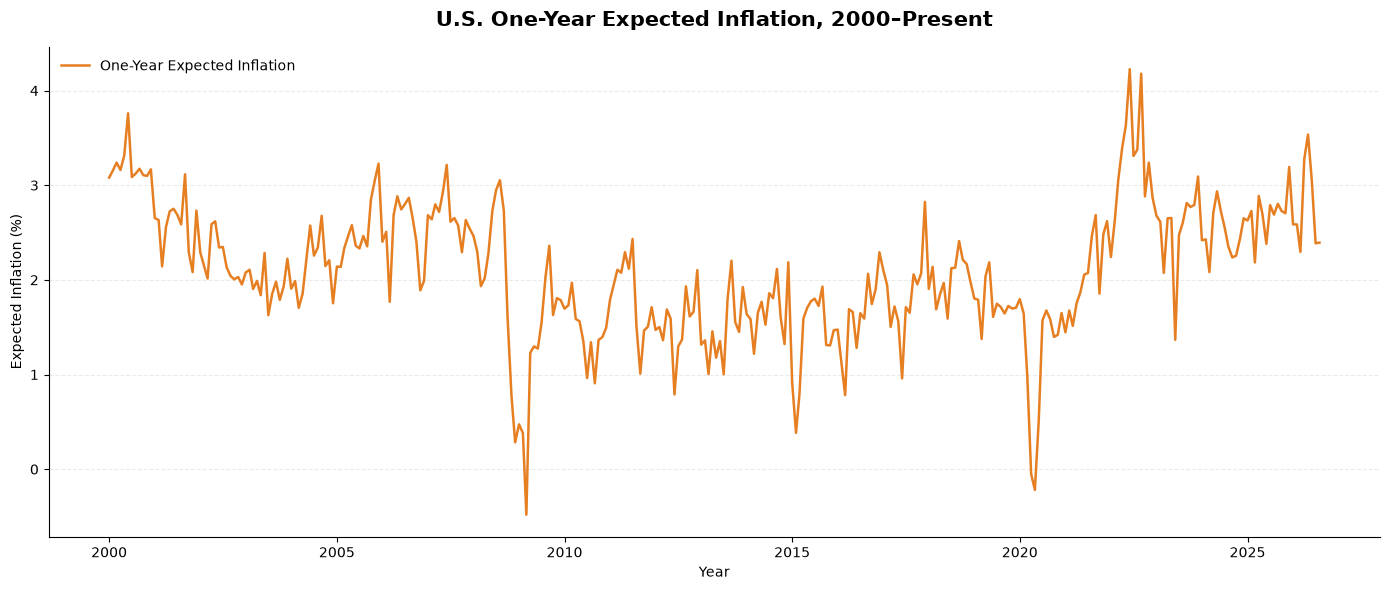

Figure saved to: d:\Project_Intern\us-real-interest-rate-analysis\outputs\expected_inflation.png


In [40]:
# Vẽ biểu đồ lạm phát kỳ vọng
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    expected_df.index,
    expected_df["expected_inflation"],
    color="#E67E22",
    linewidth=1.8,
    label="One-Year Expected Inflation"
)

ax.set_title(
    "U.S. One-Year Expected Inflation, 2000–Present",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Expected Inflation (%)")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

figure_file = output_directory / "expected_inflation.png"

fig.savefig(figure_file, dpi=300, bbox_inches="tight")

plt.show()
print(f"Figure saved to: {figure_file}")